In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from pathlib import Path

In [2]:
CSV = Path("data") / "first_25000_rows.csv" 
# may also use
# CSV = Path("data") / "orderbook.csv" 
df  = pd.read_csv(CSV, parse_dates=["ts_event"])  
df.sort_values("ts_event", inplace=True)

df.head(3)

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21 11:54:29.221064336+00:00,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21 11:54:29.223769812+00:00,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21 11:54:29.225030400+00:00,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


<Axes: title={'center': 'Rolling Best‐Level OFI per Symbol'}, xlabel='ts_event'>

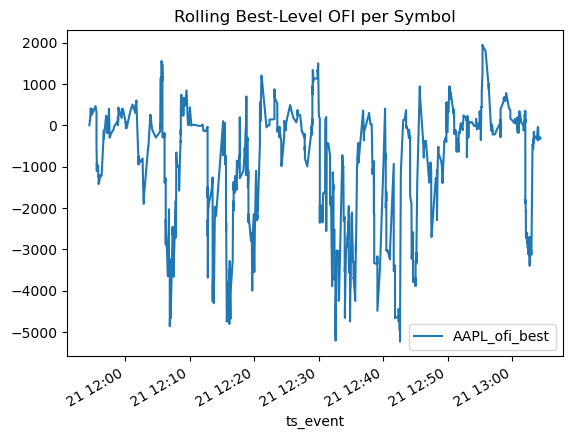

In [3]:
def compute_best_level_ofi(df, h="60s"):
    """
    Compute best‐level OFI in a trailing‐window style *per symbol*,
    aggregating duplicate timestamps before rolling so you never hit
    the “duplicate labels” error.

    Parameters
    ----------
    df : DataFrame
        Must contain cols:
          ts_event (datetime64), symbol,
          bid_px_00, bid_sz_00, ask_px_00, ask_sz_00, depth

    h : str
        Rolling‐window length, e.g. "60s".

    Returns
    -------
    ofi_best : DataFrame
        Indexed by ts_event (unique), columns = <symbol>_ofi_best.
    """
    # 1) Keep only best‐level quotes
    best = df[df["depth"] == 0].copy()
    best["ts_event"] = pd.to_datetime(best["ts_event"])
    
    series_list = []
    
    # 2) Process one symbol at a time
    for sym, g in best.groupby("symbol", sort=False):
        # sort & index
        g = g.sort_values("ts_event").set_index("ts_event")
        
        # 3) Lag quotes by one event
        g["bid_px_prev"] = g["bid_px_00"].shift()
        g["ask_px_prev"] = g["ask_px_00"].shift()
        g["bid_sz_prev"] = g["bid_sz_00"].shift()
        g["ask_sz_prev"] = g["ask_sz_00"].shift()
        
        # 4) Compute the 4 diffs
        d_bp = g["bid_px_00"] - g["bid_px_prev"]
        d_ap = g["ask_px_00"] - g["ask_px_prev"]
        d_bs = g["bid_sz_00"] - g["bid_sz_prev"]
        d_as = g["ask_sz_00"] - g["ask_sz_prev"]
        
        # 5) Eq.(1) contributions
        bid_up   =  np.where(d_bp > 0,  g["bid_sz_00"], 0.0)
        bid_down = -np.where(d_bp < 0,  g["bid_sz_00"], 0.0)
        bid_same =  np.where(d_bp == 0, d_bs,           0.0)
        
        ask_down = -np.where(d_ap < 0,  g["ask_sz_00"], 0.0)
        ask_up   =  np.where(d_ap > 0,  g["ask_sz_00"], 0.0)
        ask_same =  np.where(d_ap == 0, d_as,           0.0)
        
        g["ofi_evt"] = (bid_up + bid_down + bid_same) - (ask_down + ask_up + ask_same)
        
        # 6) **Collapse duplicate timestamps** by summing
        ofi_evt = g["ofi_evt"].groupby(level=0).sum()
        # now ofi_evt.index is unique
        
        # 7) Rolling sum over the past h‐seconds
        ofi_roll = (ofi_evt
                    .rolling(window=h, closed="right", min_periods=1)
                    .sum()
                    .rename(f"{sym}_ofi_best"))
        
        series_list.append(ofi_roll)
    
    # 8) Put all symbols side by side
    ofi_best = pd.concat(series_list, axis=1).fillna(0)
    ofi_best.index.name = "ts_event"
    return ofi_best


ofi_best = compute_best_level_ofi(df, h="60s")
ofi_best.plot(title="Rolling Best‐Level OFI per Symbol")

<Axes: title={'center': 'Rolling Multi-Level OFI per Symbol'}, xlabel='ts_event'>

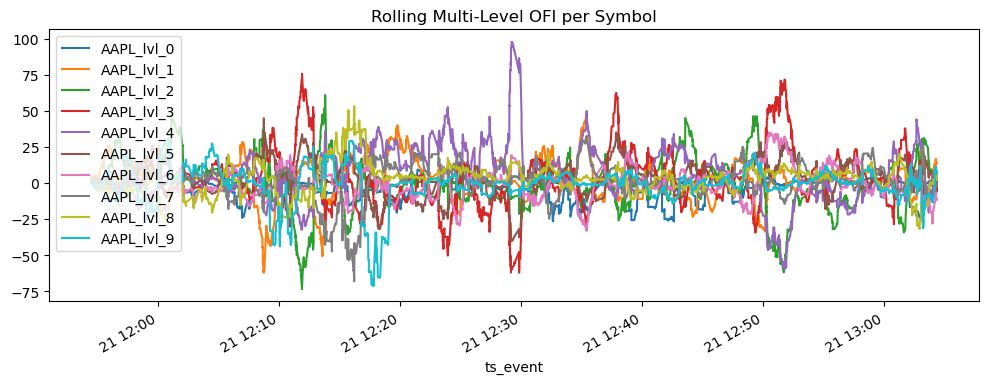

In [4]:

def compute_multi_level_ofi_rolling(df, h="60s", M=10):
    """
    Trailing-window multi-level OFI per symbol, with duplicate ts_event
    collapsed so rolling() never complains about duplicate labels.
    Returns a wide DataFrame indexed by ts_event, columns:
      <symbol>_lvl_0 … <symbol>_lvl_{M-1}
    """
    df = df.copy()
    df["ts_event"] = pd.to_datetime(df["ts_event"])

    per_sym = []
    for sym, g in df.groupby("symbol", sort=False):
        # 1) time-sort & index
        g = g.sort_values("ts_event").set_index("ts_event")

        # 2) compute event-level OFI at each depth m
        for m in range(M):
            bp, bq = f"bid_px_{m:02d}", f"bid_sz_{m:02d}"
            ap, aq = f"ask_px_{m:02d}", f"ask_sz_{m:02d}"
            prev = g[[bp, bq, ap, aq]].shift()

            d_bp = g[bp] - prev[bp]
            d_bq = g[bq] - prev[bq]
            d_ap = g[ap] - prev[ap]
            d_aq = g[aq] - prev[aq]

            of_b = (
                np.where(d_bp > 0,  g[bq], 0.0)
              + np.where(d_bp < 0, -g[bq], 0.0)
              + np.where(d_bp == 0, d_bq,  0.0)
            )
            of_a = (
                np.where(d_ap < 0, -g[aq], 0.0)
              + np.where(d_ap > 0,  g[aq], 0.0)
              + np.where(d_ap == 0, d_aq,  0.0)
            )
            
            g[f"OF_{m}"] = of_b - of_a

        # 3) collapse duplicates by summing all OF_m at identical ts_event
        ofi_evt = g[[f"OF_{m}" for m in range(M)]].groupby(level=0).sum()

        # 4) collapse sizes too (for Q normalization)
        depth_cols = [f"bid_sz_{m:02d}" for m in range(M)] + [f"ask_sz_{m:02d}" for m in range(M)]
        size_df  = g[depth_cols].groupby(level=0).sum()

        # 5) rolling sums over trailing window h
        ofi_roll   = ofi_evt.rolling(window=h, closed="right", min_periods=1).sum()
        size_roll  = size_df.rolling(window=h, closed="right", min_periods=1).sum()
        n_events   = ofi_evt.iloc[:,0].rolling(window=h, closed="right", min_periods=1).count()

        # 6) compute Q_{M,h} = total size / (2 M * #events)
        Q = size_roll.sum(axis=1).div(2 * M * n_events)

        # 7) normalize and prefix column names
        ofi_ml = ofi_roll.div(Q, axis=0)
        ofi_ml.columns = [f"{sym}_lvl_{m}" for m in range(M)]

        per_sym.append(ofi_ml)

    # 8) combine all symbols side by side
    result = pd.concat(per_sym, axis=1).sort_index()
    return result

# Usage example
df_roll = compute_multi_level_ofi_rolling(df, h="60s", M=10)
df_roll.plot(figsize=(12, 4), title="Rolling Multi-Level OFI per Symbol")

<Axes: title={'center': 'Integrated OFI (first PC projection)'}, xlabel='ts_event'>

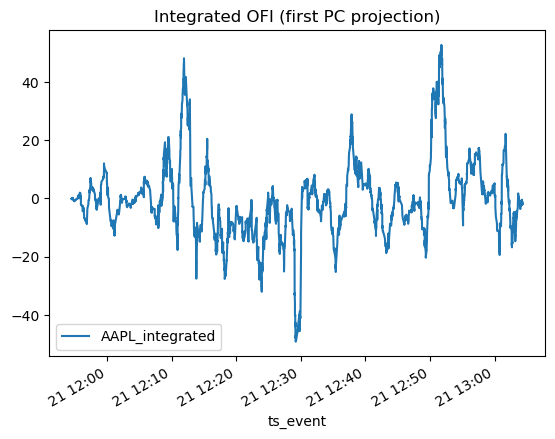

In [5]:
def compute_integrated_ofi(df_roll, M=10):
    """
    Given a DataFrame df_roll indexed by ts_event with columns
      <symbol>_lvl_0 … <symbol>_lvl_{M-1},
    compute for each symbol the integrated OFI series
      ofi_integrated[t] = v · (x_t – μ),
    where v is the first principal component (unit-norm) and μ is the mean vector.
    
    Returns a DataFrame indexed by the same ts_event, with one column per symbol:
      <symbol>_integrated
    """
    integrated = []
    # find all symbols by splitting out the "_lvl_" suffix
    lvl_cols = [c for c in df_roll.columns if "_lvl_" in c]
    symbols  = sorted({c.split("_lvl_")[0] for c in lvl_cols})
    
    for sym in symbols:
        cols = [f"{sym}_lvl_{m}" for m in range(M)]
        X = df_roll[cols].fillna(0).values   # shape (T, M)
        
        # 1) fit PCA to get first-PC direction (unit vector) and mean
        pca = PCA(n_components=1)
        pca.fit(X)
        v  = pca.components_[0]       
        # shape (M,)

        
        # 2) project each OFI vector x_t onto v after centering
        scores     = X.dot(v) / np.sum(np.abs(v))      # shape (T,)
        
        # 3) store as a Series
        s = pd.Series(
            scores,
            index=df_roll.index,
            name=f"{sym}_integrated"
        )
        integrated.append(s)
    
    # 4) combine all symbols side by side
    return pd.concat(integrated, axis=1)

# Usage:
df_roll = compute_multi_level_ofi_rolling(df, h="60s", M=10)
df_integrated = compute_integrated_ofi(df_roll, M=10)
df_integrated.plot(title="Integrated OFI (first PC projection)")

<Axes: xlabel='ts_event'>

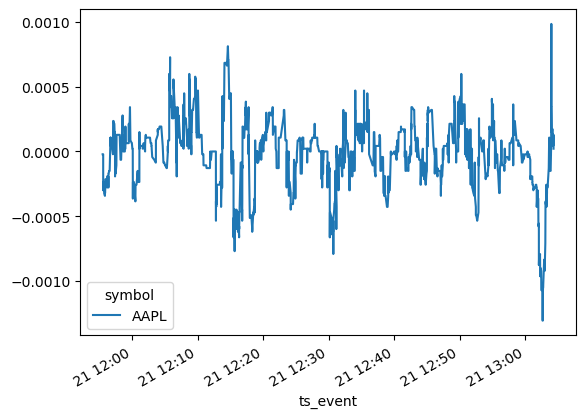

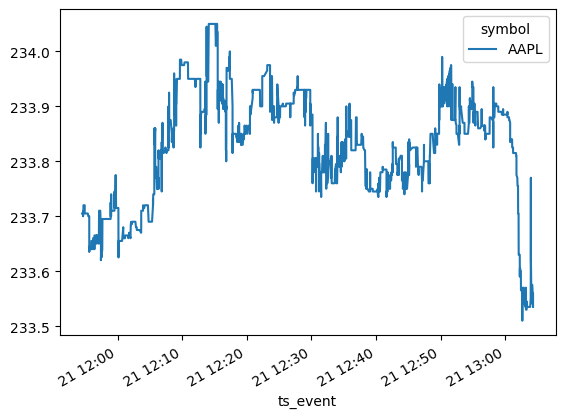

In [6]:
def compute_mid_price(df):
    """
    Compute the event‐level mid‐price per symbol.

    Parameters
    ----------
    df : DataFrame
        Must contain columns:
          ts_event (datetime64 or convertible),
          symbol,
          bid_px_00, ask_px_00.

    Returns
    -------
    mid : DataFrame
        Indexed by unique ts_event, columns = each symbol,
        values = (bid_px_00 + ask_px_00) / 2 at that event.
    """
    
    tmp = df.copy()
    tmp["ts_event"] = pd.to_datetime(tmp["ts_event"])

    # 2) Compute mid price
    tmp["mid_price"] = (tmp["bid_px_00"] + tmp["ask_px_00"]) * 0.5

    # 3) Collapse duplicates: keep the *last* mid_price at each ts_event per symbol
    mid = (
        tmp
        .groupby(["ts_event", "symbol"], sort=False)["mid_price"]
        .last()
        .unstack(fill_value=np.nan)
    )

    mid.index.name = "ts_event"
    return mid


def compute_log_returns(mid_df, h="60s"):
    """
    Compute log-returns r_{i,t} = log(P_{i,t} / P_{i,t-h}) for each symbol i
    at each event timestamp t, using the last available mid-price at or
    before t-h.

    Parameters
    ----------
    mid_df : DataFrame
        Indexed by ts_event (DatetimeIndex), columns = symbols,
        values = event-level mid-prices.
    h : str or pd.Timedelta
        Lookback interval (e.g. "60s" for 60 seconds).

    Returns
    -------
    log_ret : DataFrame
        Same shape & index as mid_df; each entry is the log-return
        over the preceding h seconds (NaN if no prior price exists).
    """
    # 1) Ensure a proper DatetimeIndex
    df = mid_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 2) Build the shifted‐back index: t-h
    delta = pd.to_timedelta(h)
    prev_times = df.index - delta
    
    prev_df = df.reindex(prev_times, method="ffill")
    prev_df.index = df.index

    # 4) Compute log-returns
    log_ret = np.log(df / prev_df)

    return log_ret


mid_df = compute_mid_price(df)
log_returns = compute_log_returns(mid_df, h="60s")

log_returns.plot()
mid_df.plot()

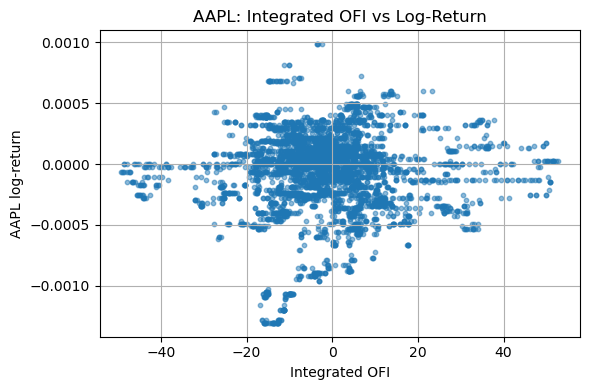

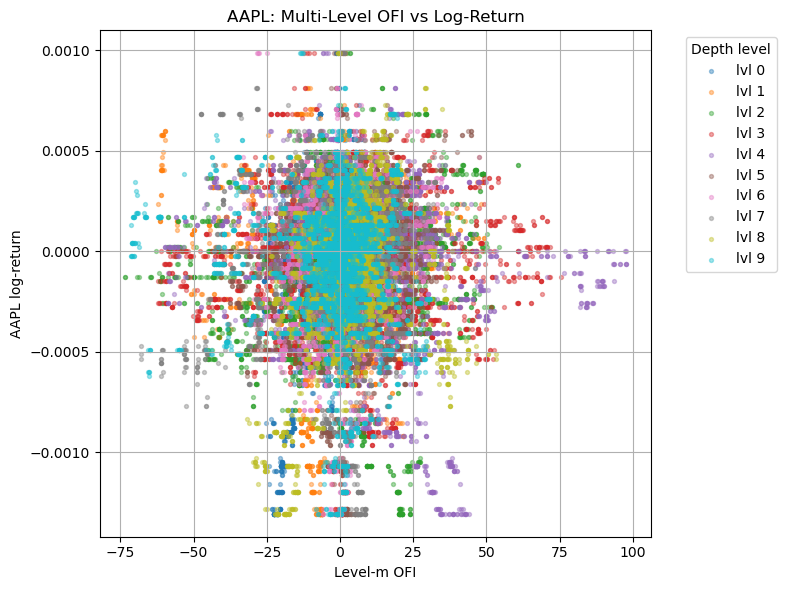

In [7]:
import matplotlib.pyplot as plt

def plot_integrated_vs_return(df_integrated, log_returns):
    """
    For each symbol, scatter integrated OFI (x) vs. log-return (y).
    """
    # infer symbols
    symbols = [c.replace('_integrated','') for c in df_integrated.columns]

    for sym in symbols:
        x = df_integrated[f"{sym}_integrated"]
        y = log_returns[sym]

        plt.figure(figsize=(6,4))
        plt.scatter(x, y, alpha=0.5, s=10)
        plt.xlabel("Integrated OFI")
        plt.ylabel(f"{sym} log-return")
        plt.title(f"{sym}: Integrated OFI vs Log-Return")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


def plot_multilevel_vs_return(df_roll, log_returns, M=10):
    """
    For each symbol, overlay scatter of OFI level 0…M-1 (x) vs. log-return (y).
    """
    # discover symbols by splitting on '_lvl_'
    all_cols = df_roll.columns
    symbols  = sorted({col.split("_lvl_")[0] for col in all_cols})

    for sym in symbols:
        plt.figure(figsize=(8,6))
        for m in range(M):
            col = f"{sym}_lvl_{m}"
            if col not in df_roll.columns:
                continue
            x = df_roll[col]
            y = log_returns[sym]
            plt.scatter(x, y, alpha=0.4, s=8, label=f"lvl {m}")

        plt.xlabel("Level-m OFI")
        plt.ylabel(f"{sym} log-return")
        plt.title(f"{sym}: Multi-Level OFI vs Log-Return")
        plt.legend(title="Depth level", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.grid(True)
        plt.tight_layout()
        plt.show()



    # assume you already have df_integrated, df_roll, log_returns in memory
plot_integrated_vs_return(df_integrated, log_returns)
plot_multilevel_vs_return(df_roll, log_returns, M=10)

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV

def cross_impact_lasso(df_integrated, log_returns, cv=5):
    """
    For each stock i, fit
        r_{i,t} = alpha_i + sum_j beta_{i,j} * ofi_{j,t} + noise
    via Lasso.  Returns a DataFrame indexed by target i, columns =
    ['alpha', <predictor1>, <predictor2>, …].
    Missing or un‐fittable symbols get NaNs.
    """
    # 1) Prepare X, drop the "_integrated" suffix
    X = df_integrated.copy()
    X.columns = X.columns.str.replace("_integrated", "", regex=False)

    # 2) Align on the same timestamps
    X, R = X.align(log_returns, join="inner", axis=0)

    symbols = X.columns.tolist()
    rows = []

    for target in symbols:
        # 3) response & design for this target
        y = R[target]
        mask = y.notna()
        Xi = X.loc[mask]
        yi = y.loc[mask]

        # 4) If no data, emit NaNs
        if yi.shape[0] == 0:
            row = pd.Series(
                data=np.nan,
                index=["alpha"] + symbols,
                name=target
            )
            rows.append(row)
            continue

        model = LassoCV(cv=cv, fit_intercept=True).fit(Xi, yi)

        coefs = pd.Series(
            data=np.nan,
            index=["alpha"] + symbols,
            name=target
        )
        coefs["alpha"] = model.intercept_
        coefs[symbols] = model.coef_

        rows.append(coefs)

    # 7) Combine into DataFrame
    result = pd.DataFrame(rows)
    return result

# -------------------
# Example usage:
# -------------------
df_integrated = compute_integrated_ofi(df_roll, M=10)
log_returns    = compute_log_returns(mid_df, h="60s")
cross_coefs    = cross_impact_lasso(df_integrated, log_returns, cv=5)
print(cross_coefs)

         alpha  AAPL
AAPL -0.000062   0.0


In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV

def cross_impact_lasso_by_level(df_roll, log_returns, level, cv=5):
    """
    Fit cross-impact LASSO using OFI at a specific depth level for each stock.

    Parameters
    ----------
    df_roll : DataFrame
        Indexed by ts_event, columns = "<symbol>_lvl_<m>" for various symbols.
    log_returns : DataFrame
        Indexed by ts_event, columns = symbol names, values = log-returns.
    level : int
        Depth level m to use (e.g., 0 for best-level).
    cv : int
        Number of folds for LassoCV.

    Returns
    -------
    result : DataFrame
        Index = target symbol i, columns = ['alpha'] + [all symbols j],
        values = fitted [alpha_i, beta_{i,j}, …].
    """
    # 1) Extract only columns for the specified level
    suffix = f"_lvl_{level}"
    ofi_cols = [col for col in df_roll.columns if col.endswith(suffix)]

    # 2) Build design matrix X and rename columns to symbol names
    X = df_roll[ofi_cols].copy()
    X.columns = [col.replace(suffix, "") for col in ofi_cols]

    # 3) Align X and log_returns on timestamps
    X, R = X.align(log_returns, join="inner", axis=0)
    symbols = X.columns.tolist()

    rows = []
    for target in symbols:
        # 4) Prepare response and mask out NaNs in both X and y
        y = R[target]
        valid_mask = y.notna() & X.notna().all(axis=1)
        Xi = X.loc[valid_mask]
        yi = y.loc[valid_mask]

        # 5) Handle cases with no data
        if yi.shape[0] == 0:
            na_row = pd.Series(data=np.nan, index=["alpha"] + symbols, name=target)
            rows.append(na_row)
            continue

        # 6) Fit LASSO with intercept
        model = LassoCV(cv=cv, fit_intercept=True).fit(Xi, yi)

        # 7) Collect coefficients and intercept
        coefs = pd.Series(np.nan, index=["alpha"] + symbols, name=target)
        coefs["alpha"] = model.intercept_
        coefs[symbols] = model.coef_

        rows.append(coefs)

    # 8) Compile result DataFrame
    result = pd.DataFrame(rows)
    return result


level = 1
df_roll = compute_multi_level_ofi_rolling(df, h="60s", M=10)

cross_level_coefs = cross_impact_lasso_by_level(df_roll, log_returns, level=level, cv=5)
print(cross_level_coefs)

         alpha  AAPL
AAPL -0.000062   0.0


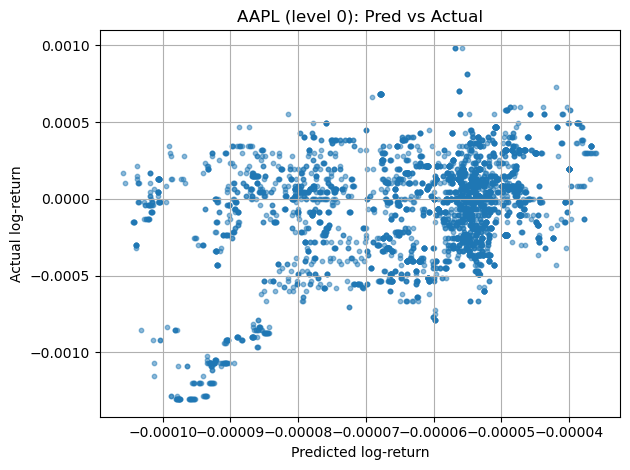

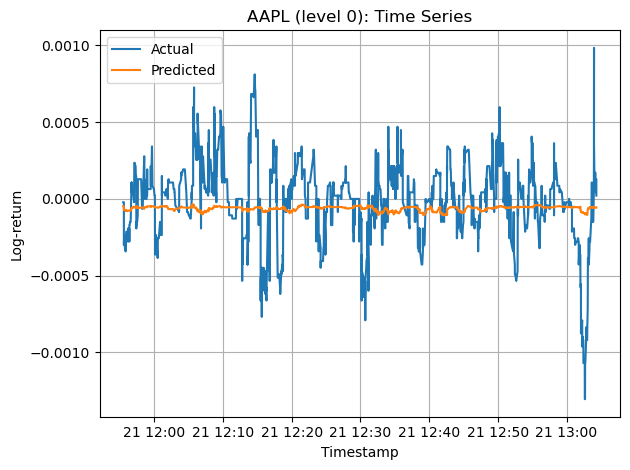

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LassoCV

def plot_lasso_performance_by_level(df_roll, log_returns, level=0, cv=5):
    """
    For a given depth level, fit LassoCV per symbol, then plot:
      1) Predicted vs. Actual log-returns (scatter)
      2) Time series of Predicted and Actual returns
    """
    # 1) Prepare X for specified level
    suffix = f"_lvl_{level}"
    ofi_cols = [col for col in df_roll.columns if col.endswith(suffix)]
    X = df_roll[ofi_cols].copy()
    X.columns = [col.replace(suffix, "") for col in ofi_cols]

    # 2) Align X and log_returns
    X, R = X.align(log_returns, join="inner", axis=0)
    symbols = X.columns.tolist()

    for sym in symbols:
        # 3) Mask out missing values
        mask = R[sym].notna() & X.notna().all(axis=1)
        Xi = X.loc[mask]
        yi = R[sym].loc[mask]

        if yi.empty:
            print(f"No data available for {sym}, skipping.")
            continue

        # 4) Fit LassoCV
        model = LassoCV(cv=cv, fit_intercept=True).fit(Xi, yi)
        yi_pred = model.predict(Xi)

        # 5) Scatter: Predicted vs. Actual
        plt.figure()
        plt.scatter(yi_pred, yi, alpha=0.5, s=10)
        plt.xlabel("Predicted log-return")
        plt.ylabel("Actual log-return")
        plt.title(f"{sym} (level {level}): Pred vs Actual")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # 6) Time series: Actual & Predicted
        plt.figure()
        plt.plot(yi.index, yi, label="Actual")
        plt.plot(yi.index, yi_pred, label="Predicted")
        plt.xlabel("Timestamp")
        plt.ylabel("Log-return")
        plt.title(f"{sym} (level {level}): Time Series")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


df_roll      = compute_multi_level_ofi_rolling(df, h="60s", M=10)
log_returns  = compute_log_returns(mid_df, h="60s")
plot_lasso_performance_by_level(df_roll, log_returns, level=0, cv=5)